In [1]:
# Imports
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC
from itertools import combinations
from sklearn.preprocessing import LabelEncoder



In [2]:
# Classes
class Perceptron:
    """Perceptron classifier.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.

    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    b_ : Scalar
      Bias unit after fitting.
    errors_ : list
      Number of misclassifications (updates) in each epoch.

    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        # if you use libarry versions stated by book use float_, else if new use float64
        # self.b_ = np.float_(0.)
        self.b_ = np.float64(0.)

        self.errors_ = []

        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_ += update * xi
                self.b_ += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
        return self

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.net_input(X) >= 0.0, 1, 0)

class AdalineGD:
    """ADAptive LInear NEuron classifier.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.


    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    b_ : Scalar
      Bias unit after fitting.
    losses_ : list
      Mean squared eror loss function values in each epoch.

    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """ Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.)
        self.losses_ = []

        for i in range(self.n_iter):
            net_input = self.net_input(X)
            # Please note that the "activation" method has no effect
            # in the code since it is simply an identity function. We
            # could write `output = self.net_input(X)` directly instead.
            # The purpose of the activation is more conceptual, i.e.,
            # in the case of logistic regression (as we will see later),
            # we could change it to
            # a sigmoid function to implement a logistic regression classifier.
            output = self.activation(net_input)
            errors = (y - output)
            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()
            loss = (errors**2).mean()
            self.losses_.append(loss)
        return self

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_) + self.b_

    def activation(self, X):
        """Compute linear activation"""
        return X

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

class AdalineSGD:
    """ADAptive LInear NEuron classifier.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    shuffle : bool (default: True)
      Shuffles training data every epoch if True to prevent cycles.
    random_state : int
      Random number generator seed for random weight
      initialization.


    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    b_ : Scalar
        Bias unit after fitting.
    losses_ : list
      Mean squared error loss function value averaged over all
      training examples in each epoch.


    """
    def __init__(self, eta=0.01, n_iter=10, shuffle=True, random_state=None):
        self.eta = eta
        self.n_iter = n_iter
        self.w_initialized = False
        self.shuffle = shuffle
        self.random_state = random_state

    def fit(self, X, y):
        """ Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : object

        """
        self._initialize_weights(X.shape[1])
        self.losses_ = []
        for i in range(self.n_iter):
            if self.shuffle:
                X, y = self._shuffle(X, y)
            losses = []
            for xi, target in zip(X, y):
                losses.append(self._update_weights(xi, target))
            avg_loss = np.mean(losses)
            self.losses_.append(avg_loss)
        return self

    def partial_fit(self, X, y):
        """Fit training data without reinitializing the weights"""
        if not self.w_initialized:
            self._initialize_weights(X.shape[1])
        if y.ravel().shape[0] > 1:
            for xi, target in zip(X, y):
                self._update_weights(xi, target)
        else:
            self._update_weights(X, y)
        return self

    def _shuffle(self, X, y):
        """Shuffle training data"""
        r = self.rgen.permutation(len(y))
        return X[r], y[r]

    def _initialize_weights(self, m):
        """Initialize weights to small random numbers"""
        self.rgen = np.random.RandomState(self.random_state)
        self.w_ = self.rgen.normal(loc=0.0, scale=0.01, size=m)
        self.b_ = np.float64(0.)
        self.w_initialized = True

    def _update_weights(self, xi, target):
        """Apply Adaline learning rule to update the weights"""
        output = self.activation(self.net_input(xi))
        error = (target - output)
        self.w_ += self.eta * 2.0 * xi * (error)
        self.b_ += self.eta * 2.0 * error
        loss = error**2
        return loss

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_) + self.b_

    def activation(self, X):
        """Compute linear activation"""
        return X

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

In [3]:
# Functions
def plot_confusion_matrix(cm, y_true):
    """
    Plots the confusion matrix using a heatmap.

    Args:
        cm (np.ndarray): The confusion matrix.
        y_true (np.ndarray): The true labels for the test data.
    """
    # Create the plot using pure matplotlib
    fig, ax = plt.subplots(figsize=(8, 6))

    # Use imshow to create the heatmap
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           # ... and label them with the unique class names
           xticklabels=np.unique(y_true), yticklabels=np.unique(y_true),
           title='Confusion Matrix',
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    fmt = 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    plt.show()

def plot_svm_decision_boundaries_multi_feature(X, y, kernels, title_prefix="", C=1.0, gamma='scale'):
    """
    Plots the decision boundaries for multiple SVM models and multiple feature pairs,
    automatically handling non-numerical target labels and different data types for y.

    Args:
        X (pd.DataFrame): The input features (must have at least 2 columns).
        y (pd.Series or np.ndarray or pd.DataFrame): The target labels.
        kernels (list): A list of kernel strings (e.g., 'linear', 'rbf', 'poly').
        title_prefix (str): A prefix for the plot titles.
        C (float): The regularization parameter.
        gamma (str or float): Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.
    """
    # Standardize the y input to a pandas Series
    if isinstance(y, pd.DataFrame):
        if y.shape[1] != 1:
            raise ValueError("If 'y' is a DataFrame, it must contain a single column.")
        y_series = y.iloc[:, 0]
    elif isinstance(y, (pd.Series, np.ndarray)):
        # Convert to Series for consistent handling, and ravel to ensure 1D
        y_series = pd.Series(y).ravel()
    else:
        raise TypeError("y must be a pandas DataFrame, Series, or a NumPy array.")

    # Check the dtype of the uniform y_series and encode if necessary
    if y_series.dtype == 'object':
        print("Encoding string labels to numerical format...")
        le = LabelEncoder()
        y_encoded = le.fit_transform(y_series)
    else:
        y_encoded = y_series.values

    n_features = X.shape[1]
    if n_features < 2:
        raise ValueError("This function requires at least 2 features for plotting combinations.")

    feature_pairs = list(combinations(range(n_features), 2))
    n_pairs = len(feature_pairs)
    n_kernels = len(kernels)

    fig, axes = plt.subplots(n_kernels, n_pairs, figsize=(n_pairs * 6, n_kernels * 5),
                             constrained_layout=True)

    # Ensure axes is a 2D array even for a single row/column
    if n_kernels == 1 and n_pairs == 1:
        axes = np.array([[axes]])
    elif n_kernels == 1:
        axes = np.array([axes])
    elif n_pairs == 1:
        axes = axes.reshape(-1, 1)

    for i, kernel in enumerate(kernels):
        for j, (f1_idx, f2_idx) in enumerate(feature_pairs):
            ax = axes[i, j]

            # Select the two features for the current plot
            X_pair = X.iloc[:, [f1_idx, f2_idx]]
            f1_name = X.columns[f1_idx]
            f2_name = X.columns[f2_idx]

            # Train the SVM model on the selected features
            if kernel == 'poly':
                model = SVC(kernel=kernel, C=C, gamma=gamma, degree=3)
            else:
                model = SVC(kernel=kernel, C=C, gamma=gamma)

            # FIT THE MODEL WITH .values TO AVOID THE WARNING
            model.fit(X_pair.values, y_encoded)

            # Plot the data points with encoded labels
            ax.scatter(X_pair.iloc[:, 0], X_pair.iloc[:, 1], c=y_encoded, cmap=plt.cm.coolwarm, s=20, edgecolors='k')

            # Create and plot the decision boundary
            xlim = ax.get_xlim()
            ylim = ax.get_ylim()
            xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 500),
                                 np.linspace(ylim[0], ylim[1], 500))
            Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
            Z = Z.reshape(xx.shape)

            ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

            # Highlight the support vectors
            ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
                       linewidth=1, facecolors='none', edgecolors='k')

            # Set titles and labels
            ax.set_title(f"{title_prefix} {kernel.capitalize()} ({f1_name} vs {f2_name})")
            ax.set_xlabel(f1_name)
            ax.set_ylabel(f2_name)
            ax.set_aspect('equal', adjustable='box')

    plt.show()

def plot_best_svm_decision_boundary(grid_search, X, y):
    """
    Plots the decision boundaries for the best SVM model found by GridSearchCV.

    Args:
        grid_search (GridSearchCV): The fitted GridSearchCV object.
        X (pd.DataFrame): The input features (must be a DataFrame for feature names).
        y (pd.Series or np.ndarray): The target labels.
    """
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    best_kernel = best_params.get('kernel', 'linear') # Default to linear if not found
    '''
    # Standardize the y input and encode if necessary
    if isinstance(y, pd.DataFrame):
        if y.shape[1] != 1:
            raise ValueError("If 'y' is a DataFrame, it must contain a single column.")
        y_series = y.iloc[:, 0]
    elif isinstance(y, (pd.Series, np.ndarray)):
        y_series = pd.Series(y).ravel()
    else:
        raise TypeError("y must be a pandas DataFrame, Series, or a NumPy array.")

    if y_series.dtype == 'object':
        print("Encoding string labels to numerical format...")
        le = LabelEncoder()
        y_encoded = le.fit_transform(y_series)
    else:
        y_encoded = y_series.values
    '''
    n_features = X.shape[1]
    if n_features < 2:
        raise ValueError("This function requires at least 2 features for plotting combinations.")

    feature_pairs = list(combinations(range(n_features), 2))
    n_pairs = len(feature_pairs)

    fig, axes = plt.subplots(1, n_pairs, figsize=(n_pairs * 6, 6), constrained_layout=True)

    # Ensure axes is an array even for a single subplot
    if n_pairs == 1:
        axes = [axes]

    for j, (f1_idx, f2_idx) in enumerate(feature_pairs):
        ax = axes[j]

        # Select the two features for the current plot
        X_pair = X.iloc[:, [f1_idx, f2_idx]]
        f1_name = X.columns[f1_idx]
        f2_name = X.columns[f2_idx]

        # Use the best model from GridSearchCV
        model = best_model

        # Since the best model was trained on the full dataset, we'll retrain
        # a new instance of it on just the two features for plotting purposes.
        # This is the most reliable way to ensure the decision boundary is correct.
        plot_model = SVC(
            kernel=best_params.get('kernel'),
            C=best_params.get('C'),
            gamma=best_params.get('gamma')
        )
        if best_kernel == 'poly':
            plot_model.degree = best_params.get('degree', 3) # Handle poly degree separately
        plot_model.fit(X_pair.values, y)

        # Plot the data points
        ax.scatter(X_pair.iloc[:, 0], X_pair.iloc[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')

        # Create and plot the decision boundary
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 500),
                             np.linspace(ylim[0], ylim[1], 500))
        Z = plot_model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

        # Highlight the support vectors
        ax.scatter(plot_model.support_vectors_[:, 0], plot_model.support_vectors_[:, 1], s=100,
                   linewidth=1, facecolors='none', edgecolors='k')

        # Set titles and labels
        ax.set_title(f"Best Model ({best_kernel.capitalize()} kernel)\n({f1_name} vs {f2_name})")
        ax.set_xlabel(f1_name)
        ax.set_ylabel(f2_name)
        ax.set_aspect('equal', adjustable='box')

    plt.suptitle(f"GridSearchCV Best Model Decision Boundaries\nBest Params: {best_params}", y=1.05)
    plt.show()

In [4]:
# Read in data
project_adult = pd.read_csv('project_adult.csv')
project_validation = pd.read_csv('project_validation_inputs.csv')

In [5]:
#Preprocessing


#Drop first ID column and 'fnlwgt' and education-num column
project_adult = project_adult.drop(project_adult.columns[0], axis=1)
project_adult = project_adult.drop(['fnlwgt', 'education-num'], axis=1)
project_validation = project_validation.drop(project_validation.columns[0], axis=1)
project_validation = project_validation.drop(['fnlwgt', 'education-num'], axis=1)

#Split project_adult between x, y
X = project_adult.iloc[:, :-1]
y = project_adult.iloc[:, -1]

#Split X, y into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numerical_features = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']

# One hot encode categorical features
y_train = y_train.apply(lambda x: 1 if '>50K' in x else 0)
y_test = y_test.apply(lambda x: 1 if '>50K' in x else 0)

categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

# Create a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), categorical_features)
    ])

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


y_train = y_train.reset_index(drop=True).to_numpy()
y_test = y_test.reset_index(drop=True).to_numpy()

X_validation = project_validation
X_validation = preprocessor.transform(X_validation)


Accuracy: 0.8170825335892514


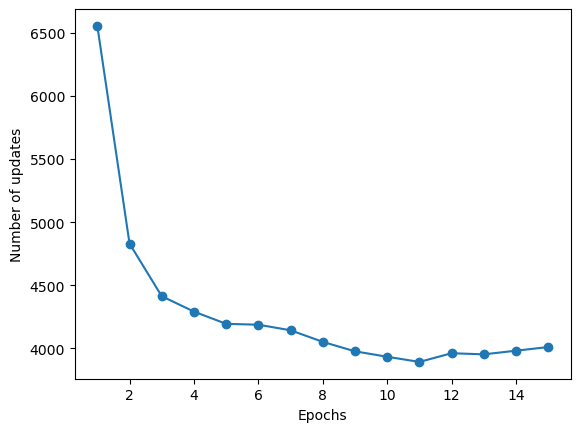

In [6]:
# Train perceptron from class
ppn = Perceptron(eta=0.00001, n_iter=15, random_state=1)
ppn.fit(X_train, y_train)
y_pred = ppn.predict(X_test)

# Make predictions
y_pred = ppn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# Plot MSE for each epoch
plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Number of updates')
plt.show()

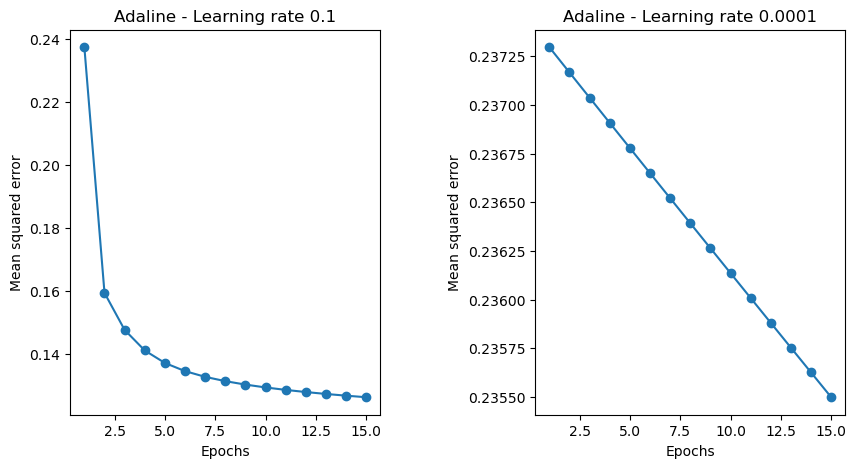

In [7]:
# Train adaptive linear neuron with AdalineGD with 2 different learning rates
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

ada1 = AdalineGD(n_iter=15, eta=0.1).fit(X_train, y_train)
ax[0].plot(range(1, len(ada1.losses_) + 1), ada1.losses_, marker='o')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Mean squared error')
ax[0].set_title('Adaline - Learning rate 0.1')

ada2 = AdalineGD(n_iter=15, eta=0.0001).fit(X_train, y_train)
ax[1].plot(range(1, len(ada2.losses_) + 1), ada2.losses_, marker='o')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Mean squared error')
ax[1].set_title('Adaline - Learning rate 0.0001')

# Adjust the horizontal space between subplots
plt.subplots_adjust(wspace=0.5)
plt.show()

In [8]:
# predict on trained AdalineGD models
n_temp = 15
e_temp = 0.1
y_pred =ada1.predict(X_test)
print(f"Adaline accuracy with n_iter {n_temp} and eta {e_temp}: {accuracy_score(y_test, y_pred):.4f}")

n_temp = 15
e_temp = 0.0001
y_pred =ada2.predict(X_test)
print(f"Adaline accuracy with n_iter {n_temp} and eta {e_temp}: {accuracy_score(y_test, y_pred):.4f}")

Adaline accuracy with n_iter 15 and eta 0.1: 0.8182
Adaline accuracy with n_iter 15 and eta 0.0001: 0.7685


Adaline accuracy with n_iter 1 and eta 0.1: 0.7712
Adaline accuracy with n_iter 1 and eta 0.01: 0.7685
Adaline accuracy with n_iter 1 and eta 0.001: 0.7685
Adaline accuracy with n_iter 1 and eta 0.0001: 0.7685
Adaline accuracy with n_iter 1 and eta 1e-05: 0.7685
Adaline accuracy with n_iter 5 and eta 0.1: 0.7960
Adaline accuracy with n_iter 5 and eta 0.01: 0.7685
Adaline accuracy with n_iter 5 and eta 0.001: 0.7685
Adaline accuracy with n_iter 5 and eta 0.0001: 0.7685
Adaline accuracy with n_iter 5 and eta 1e-05: 0.7685
Adaline accuracy with n_iter 10 and eta 0.1: 0.8063
Adaline accuracy with n_iter 10 and eta 0.01: 0.7685
Adaline accuracy with n_iter 10 and eta 0.001: 0.7685
Adaline accuracy with n_iter 10 and eta 0.0001: 0.7685
Adaline accuracy with n_iter 10 and eta 1e-05: 0.7685
Adaline accuracy with n_iter 15 and eta 0.1: 0.8182
Adaline accuracy with n_iter 15 and eta 0.01: 0.7714
Adaline accuracy with n_iter 15 and eta 0.001: 0.7685
Adaline accuracy with n_iter 15 and eta 0.0001:

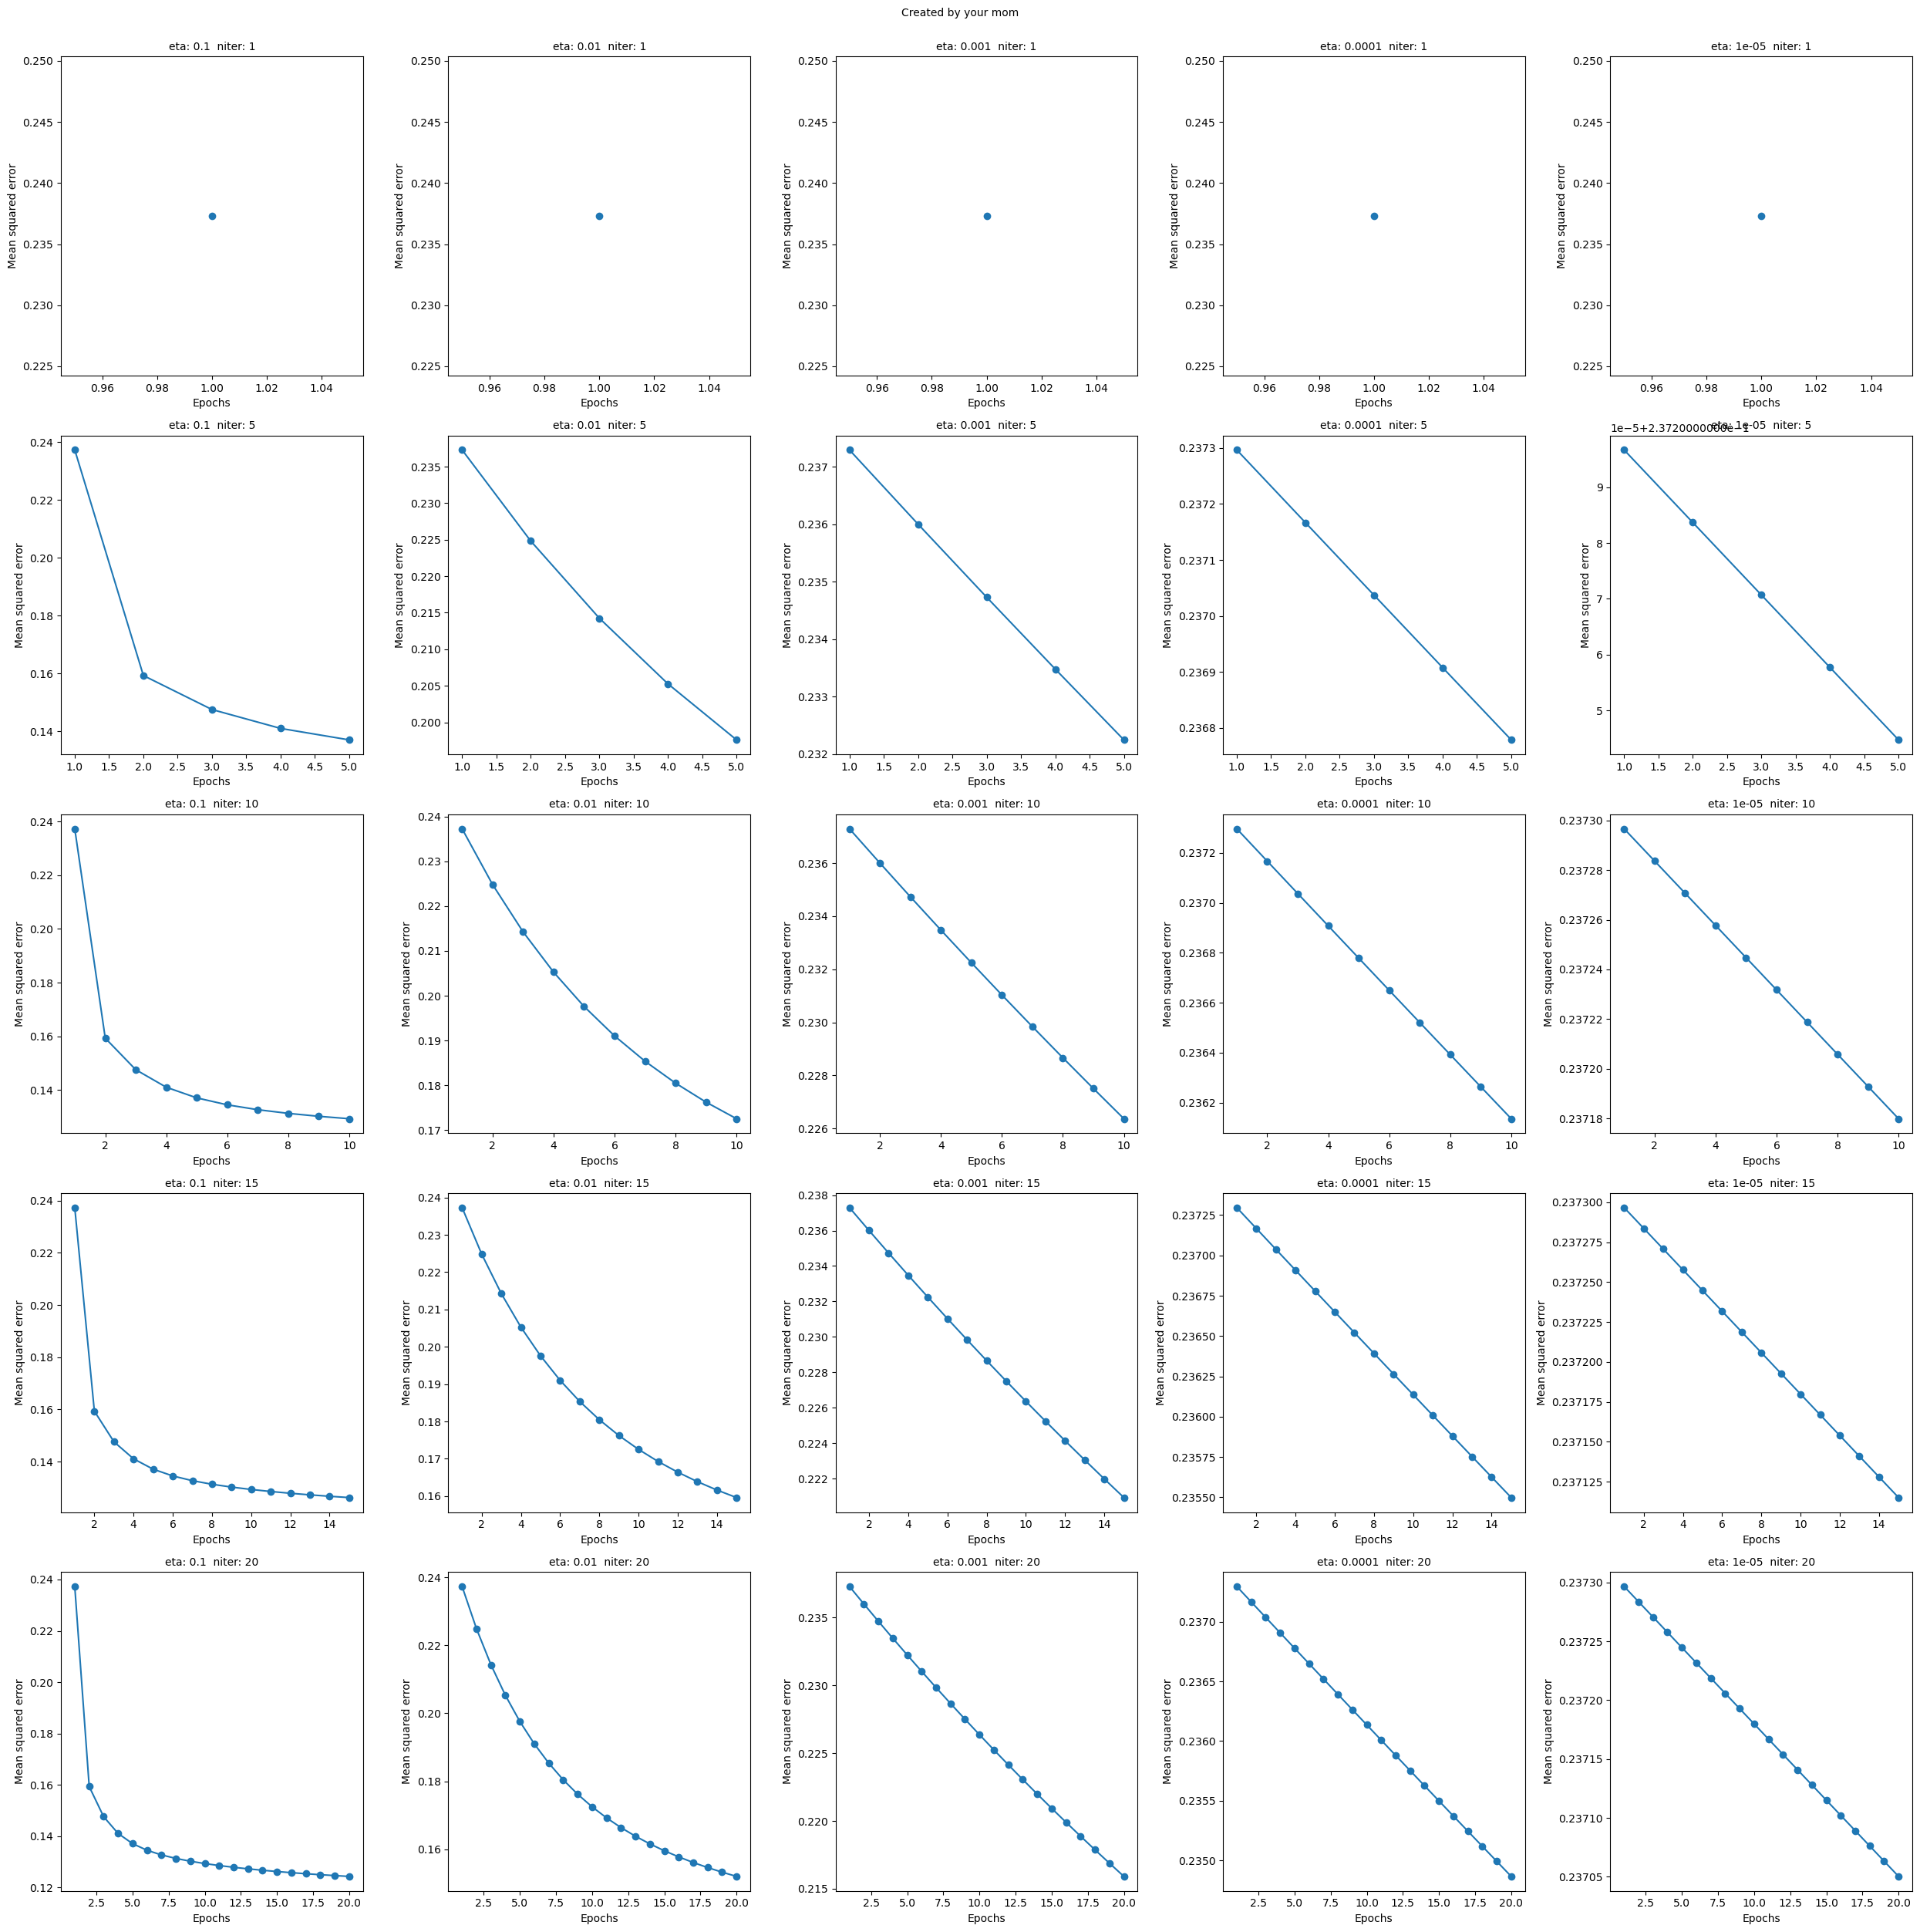

In [9]:
# looking at parameters eta and n_iter
fig, ax = plt.subplots(nrows=5, ncols=5, figsize=(25, 25))

list_eta = [.1, 0.01, 0.001, 0.0001, 0.00001]
list_niter = [1, 5, 10, 15, 20]

fig.suptitle("Created by your mom", fontsize=10, y=1)

for j, n_temp in enumerate(list_niter):

    for i, e_temp in enumerate(list_eta):
        ada = AdalineGD(n_iter=n_temp, eta= e_temp).fit(X_train, y_train)
        ax[j, i].plot(range(1, len(ada.losses_) + 1), ada.losses_, marker='o')
        ax[j, i].set_xlabel('Epochs', fontsize=10)
        ax[j, i].set_ylabel('Mean squared error', fontsize=10)
        ax[j, i].set_title(f"eta: {e_temp}  niter: {n_temp}", fontsize=10)

        y_pred = ada.predict(X_test)
        print(f"Adaline accuracy with n_iter {n_temp} and eta {e_temp}: {accuracy_score(y_test, y_pred):.4f}")

plt.tight_layout()
plt.show()

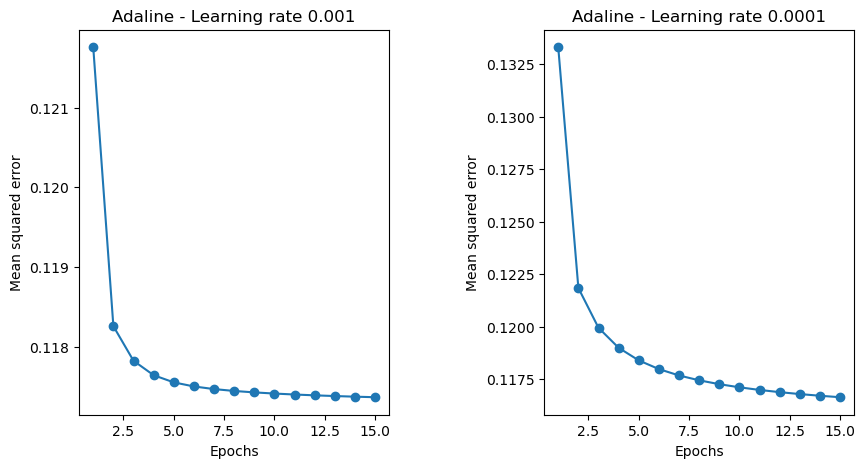

In [10]:
# Train adaptive linear neuron with AdalineSGD with 2 different learning rates.....without shuffling
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

ada1 = AdalineSGD(n_iter=15, eta=0.001, shuffle=False).fit(X_train, y_train)
ax[0].plot(range(1, len(ada1.losses_) + 1), ada1.losses_, marker='o')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Mean squared error')
ax[0].set_title('Adaline - Learning rate 0.001')

ada2 = AdalineSGD(n_iter=15, eta=0.0001, shuffle=False).fit(X_train, y_train)
ax[1].plot(range(1, len(ada2.losses_) + 1), ada2.losses_, marker='o')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Mean squared error')
ax[1].set_title('Adaline - Learning rate 0.0001')

# Adjust the horizontal space between subplots
plt.subplots_adjust(wspace=0.5)

# plt.savefig('images/02_11.png', dpi=300)
plt.show()

In [11]:
# predict on trained AdalineSGD models with shuffle FALSE
y_pred =ada1.predict(X_test)
print(f"Adaline accuracy with n_iter 15 and eta 0.1: {accuracy_score(y_test, y_pred):.4f}")

y_pred =ada2.predict(X_test)
print(f"Adaline accuracy with n_iter 15 and eta 0.0001: {accuracy_score(y_test, y_pred):.4f}")

Adaline accuracy with n_iter 15 and eta 0.1: 0.8424
Adaline accuracy with n_iter 15 and eta 0.0001: 0.8403


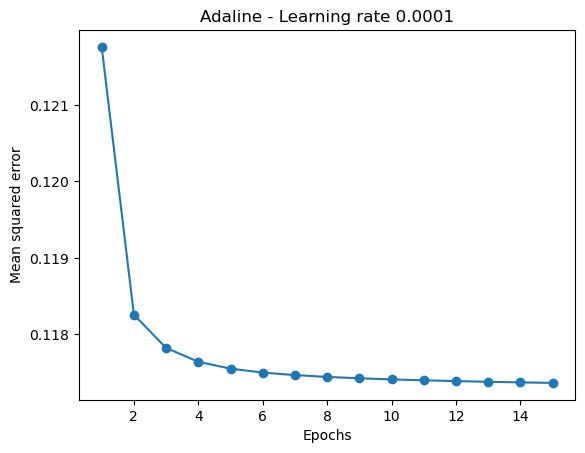

In [12]:
fig, ax = plt.subplots()
ada3 = AdalineSGD(n_iter=15, eta=0.0001, shuffle=True).fit(X_train, y_train)
ax.plot(range(1, len(ada1.losses_) + 1), ada1.losses_, marker='o')
ax.set_xlabel('Epochs')
ax.set_ylabel('Mean squared error')
ax.set_title('Adaline - Learning rate 0.0001')
plt.show()

In [13]:
# predict on trained AdalineSGD models with shuffle true
y_pred =ada3.predict(X_test)
print(f"Adaline accuracy with n_iter 15 and eta 0.0001: {accuracy_score(y_test, y_pred):.4f}")

Adaline accuracy with n_iter 15 and eta 0.0001: 0.8397


In [14]:
# Scikit-learn Perceptron
sk_ppn = SklearnPerceptron(eta0=0.1, max_iter=15, random_state=42)
sk_ppn.fit(X_train, y_train)
sk_y_pred_ppn = sk_ppn.predict(X_test)
print(f"Scikit-learn Perceptron accuracy: {accuracy_score(y_test, sk_y_pred_ppn):.4f}")

# Scikit-learn Adaline (using SGDClassifier with 'log_loss' is closer, but 'perceptron' is available)
# For Adaline (which uses GD), SGDClassifier with 'hinge' loss is a good proxy, as it's a linear classifier with regularization
sk_ada = SGDClassifier(loss='perceptron', eta0=0.0001, learning_rate='constant', max_iter=15, random_state=42)
sk_ada.fit(X_train, y_train)
sk_y_pred_ada = sk_ada.predict(X_test)
print(f"Scikit-learn Adaline (SGDClassifier) accuracy: {accuracy_score(y_test, sk_y_pred_ada):.4f}")

Scikit-learn Perceptron accuracy: 0.7516
Scikit-learn Adaline (SGDClassifier) accuracy: 0.7689


In [30]:
# predict validation set using scikit learn perceptron
sk_ppn_y_validation = sk_ppn.predict(X_validation)
# Convert back to income labels
income_labels = ['<=50K', '>50K']
y_validation_labels = pd.Series(sk_ppn_y_validation).map({0: '<=50K', 1: '>50K'})

# Create a DataFrame with the column labeled 'income'
y_validation_labels = pd.DataFrame({'income': y_validation_labels})
y_validation_labels.head()
# Write to CSV
y_validation_labels.to_csv('Group_25_Perceptron_PredictedOutputs.csv', index=False)


In [31]:
# predict validation set using scikit learn adaline
sk_ada_y_validation = sk_ada.predict(X_validation)
# Convert back to income labels
income_labels = ['<=50K', '>50K']
y_validation_labels = pd.Series(sk_ada_y_validation).map({0: '<=50K', 1: '>50K'})

# Create a DataFrame with the column labeled 'income'
y_validation_labels = pd.DataFrame({'income': y_validation_labels})
y_validation_labels.head()
# Write to CSV
y_validation_labels.to_csv('Group_25_Adaline_PredictedOutputs.csv', index=False)

In [15]:
# Predict validation set
y_validation =ada1.predict(X_validation)
# Convert back to income labels
income_labels = ['<=50K', '>50K']
y_validation_labels = pd.Series(y_validation).map({0: '<=50K', 1: '>50K'})

# Create a DataFrame with the column labeled 'income'
df_validation = pd.DataFrame({'income': y_validation_labels})
df_validation.head()

,income
0,<=50K
1,<=50K
2,>50K
3,<=50K
4,<=50K


In [32]:
# Initialize the model with default parameters.
# For multi-class problems, LogisticRegression uses a one-vs-rest strategy by default.
# The 'solver' is set to 'lbfgs' as it's a good default for multi-class problems.
model = LogisticRegression(solver='lbfgs', random_state=42, max_iter=500)
model.fit(X_train, y_train)

LogisticRegression(max_iter=500, random_state=42)

In [33]:
# Make predictions on the scaled test set.
y_pred = model.predict(X_test)

In [34]:
# predict validation set using scikit learn adaline
sk_logreg_y_validation = model.predict(X_validation)
# Convert back to income labels
income_labels = ['<=50K', '>50K']
y_validation_labels = pd.Series(sk_logreg_y_validation).map({0: '<=50K', 1: '>50K'})

# Create a DataFrame with the column labeled 'income'
y_validation_labels = pd.DataFrame({'income': y_validation_labels})
y_validation_labels.head()
# Write to CSV
y_validation_labels.to_csv('Group_25_LogisticRegression_PredictedOutputs.csv', index=False)


--- Confusion Matrix ---
[[3686  318]
 [ 471  735]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      4004
           1       0.70      0.61      0.65      1206

    accuracy                           0.85      5210
   macro avg       0.79      0.77      0.78      5210
weighted avg       0.84      0.85      0.84      5210



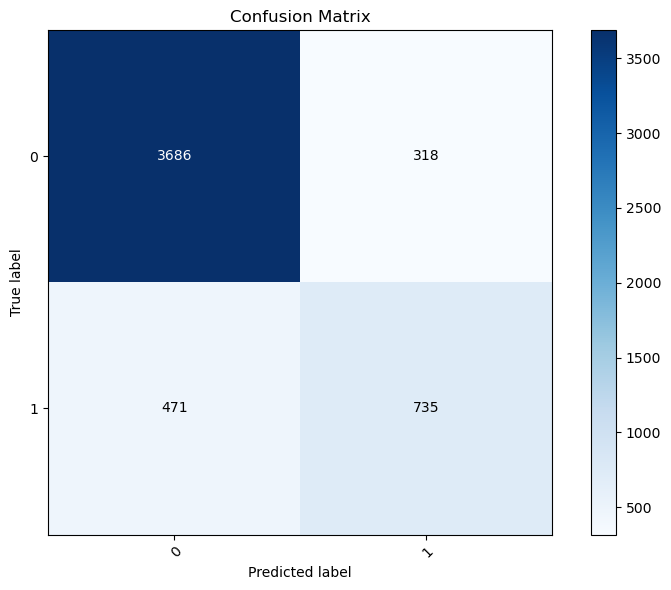

In [18]:
# Generate and display the confusion matrix and classification report
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Plot the predictions and the confusion matrix
plot_confusion_matrix(cm, y_test)

In [27]:
#Train with various c values
C_values = [0.01, 1, 100]
for c in C_values:
    model = LogisticRegression(solver='lbfgs', random_state=42, max_iter=500, C=c)
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    print(f"C={c}: Accuracy={accuracy:.4f}")


C=0.01: Accuracy=0.8466
C=1: Accuracy=0.8486
C=100: Accuracy=0.8482


In [19]:
# We use GridSearchCV to find the best hyperparameters for the model.
# Cross-validation (CV) helps to get a more robust estimate of model performance
# and prevents overfitting to a single train-test split.

# Define the parameter grid to search over.
# np.logspace(-4,4,2-) tells GridSearchCV to test 20 values for C eenly spaced on logarithmic scale from 10^-4 to 10^4
param_grid = {
    'C': np.logspace(-4, 4, 20),  # Inverse of regularization strength
}

# Initialize GridSearchCV with a 5-fold cross-validation strategy.
grid_search = GridSearchCV(
    estimator=LogisticRegression(solver='lbfgs', random_state=42, max_iter=1000),
    param_grid=param_grid,
    cv=5,                     # 5-fold cross-validation
    scoring='accuracy',       # Metric to optimize for
    n_jobs=-1,                # Use all available CPU cores
    verbose=1                 # Print progress
)

print("Starting hyperparameter search. This may take a moment...")
grid_search.fit(X_train, y_train)

Starting hyperparameter search. This may take a moment...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04])},
             scoring='accuracy', verbose=1)


--- Best Model Found by GridSearchCV ---
Best parameters: {'C': 1.623776739188721}
Best cross-validation accuracy: 0.8503

 Final evaluation of the best model on the test set...
Final accuracy on test set: 0.8491

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      4004
           1       0.70      0.61      0.65      1206

    accuracy                           0.85      5210
   macro avg       0.79      0.77      0.78      5210
weighted avg       0.84      0.85      0.85      5210


Confusion Matrix:
[[3689  315]
 [ 471  735]]


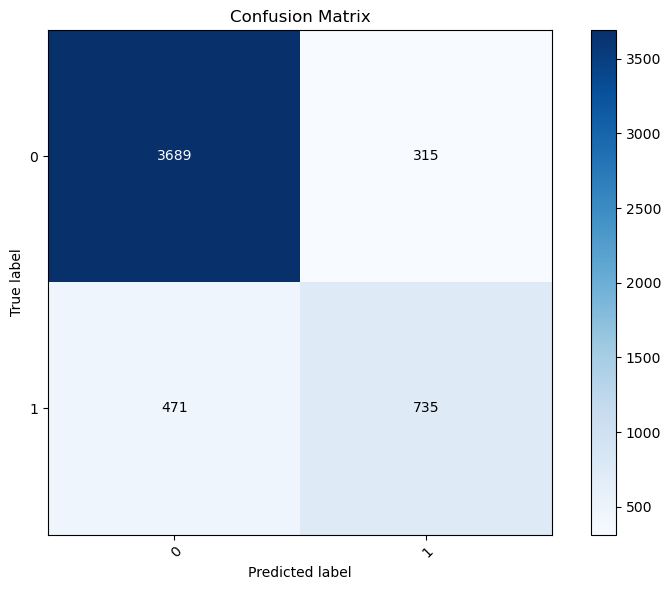

In [20]:
# Get the best estimator from the search.
best_model = grid_search.best_estimator_

print("\n--- Best Model Found by GridSearchCV ---")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

print("\n Final evaluation of the best model on the test set...")
# Predict using the best model found during the search.
final_y_pred = best_model.predict(X_test)
final_accuracy = accuracy_score(y_test, final_y_pred)

print(f"Final accuracy on test set: {final_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, final_y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, final_y_pred)
print(cm)

# Plot the predictions and the confusion matrix
plot_confusion_matrix(cm, y_test)

In [35]:
# Train with linear kernel
model_linear = SVC(kernel='linear', C=1)
model_linear.fit(X_train, y_train)

SVC(C=1, kernel='linear')

In [36]:
# Make predictions on the scaled test set.
y_pred = model_linear.predict(X_test)

In [37]:
# predict validation set using scikit learn adaline
sk_svm_y_validation = model_linear.predict(X_validation)
# Convert back to income labels
income_labels = ['<=50K', '>50K']
y_validation_labels = pd.Series(sk_svm_y_validation).map({0: '<=50K', 1: '>50K'})

# Create a DataFrame with the column labeled 'income'
y_validation_labels = pd.DataFrame({'income': y_validation_labels})
y_validation_labels.head()
# Write to CSV
y_validation_labels.to_csv('Group_25_SVM_PredictedOutputs.csv', index=False)


--- Confusion Matrix ---
[[3715  289]
 [ 483  723]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4004
           1       0.71      0.60      0.65      1206

    accuracy                           0.85      5210
   macro avg       0.80      0.76      0.78      5210
weighted avg       0.85      0.85      0.85      5210



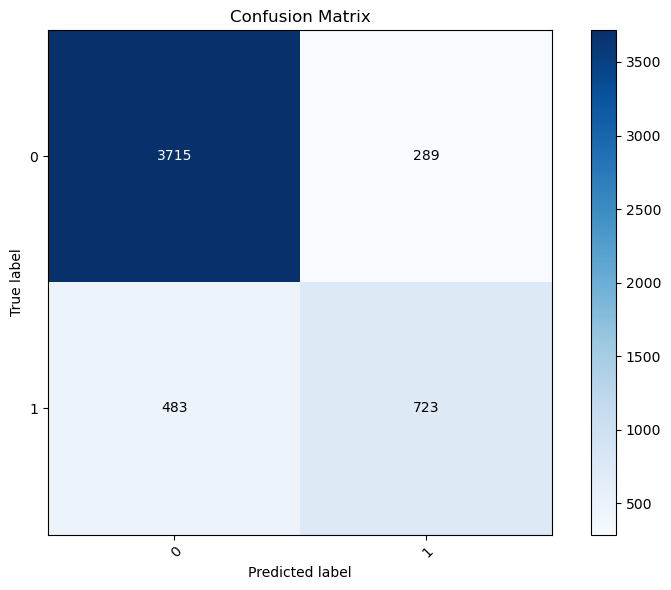

In [23]:
# Generate and display the confusion matrix and classification report
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Plot the predictions and the confusion matrix
plot_confusion_matrix(cm, y_test)

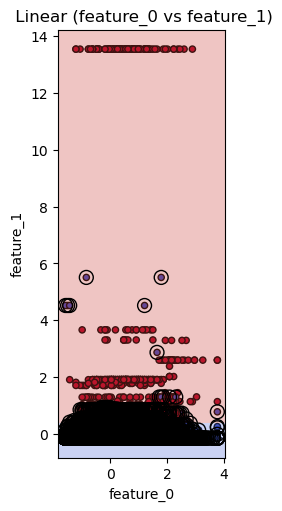

In [24]:
# Convert X_train to a DataFrame
X_train_df = pd.DataFrame(X_train, columns=[f'feature_{i}' for i in range(X_train.shape[1])])

# Convert y_train to a single-column DataFrame
y_train_df = pd.DataFrame(y_train, columns=['target'])

selected_features = ['feature_0', 'feature_1']  
plot_svm_decision_boundaries_multi_feature(
    X_train_df[selected_features],
    y_train_df,
    kernels=['linear']
)

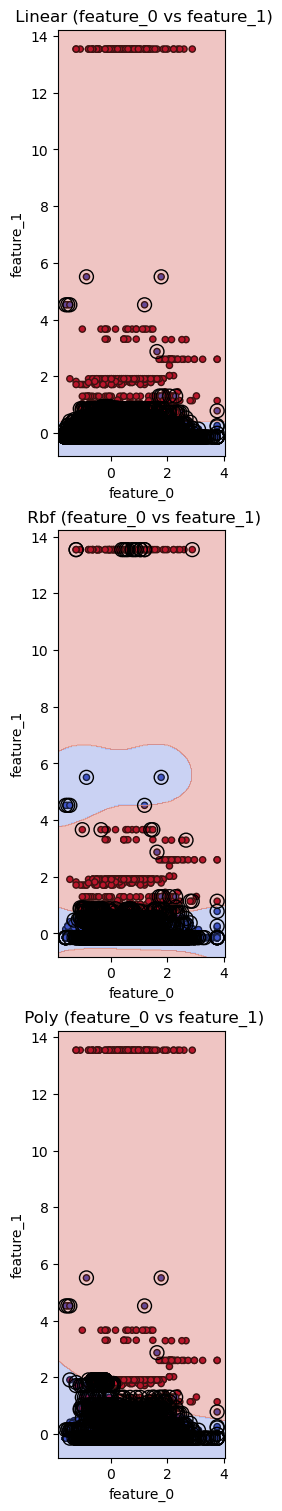

In [25]:
# Plot decision boundaries for different kernels
plot_svm_decision_boundaries_multi_feature(X_train_df[selected_features], y_train_df, kernels=['linear', 'rbf', 'poly'])

In [26]:
svm_grid = {'kernel':['linear','rbf','poly'], 'C':[0.1,1,10], 'gamma':['scale','auto']}
GridSearchCV(SVC(), svm_grid, cv=5, scoring='accuracy', n_jobs=-1)


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='accuracy')